In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import itertools
%matplotlib inline

DATA_DIR = "../data/"

def load(name):
   df = pd.read_csv(DATA_DIR + name)
   df.columns = [c.strip("# ").strip() for c in df.columns]
   return df

bt = load("bt_symmetric.csv")
calls = load("calls.csv")
sms = load("sms.csv")

In [15]:
DATA_DIR = "../data/"
DATA_FILENAMES = {"bluetooth": "bt_symmetric.csv",
                  "calls": "calls.csv",
                  "sms": "sms.csv",
                  "facebook_friends": "fb_friends.csv",
                  "genders": "genders.csv"}

In [16]:
def LoadData(data_filename, data_dir):
  '''Loads data from |data_dir|/|data_filename|. Returns Pandas dataframe.'''
  return pd.read_csv(os.path.join(data_dir, data_filename))  

In [17]:
bt = LoadData(DATA_FILENAMES["bluetooth"], DATA_DIR)
calls = LoadData(DATA_FILENAMES["calls"], DATA_DIR)
sms = LoadData(DATA_FILENAMES["sms"], DATA_DIR)
print(bt.shape, calls.shape, sms.shape)
print(bt.columns.tolist())
display(bt.head())
display(calls.head())
display(sms.head())


(5474289, 4) (3600, 4) (24333, 3)
['# timestamp', 'user_a', 'user_b', 'rssi']


,# timestamp,user_a,user_b,rssi
0,0,0,-1,0
1,0,1,-1,0
2,0,2,-1,0
3,0,3,-2,-88
4,0,5,-1,0


,timestamp,caller,callee,duration
0,184,300,301,121
1,3920,512,299,670
2,5623,301,300,504
3,9252,401,457,-1
4,15466,512,0,5


,timestamp,sender,recipient
0,18,370,512
1,37,512,370
2,126,370,512
3,134,0,512
4,312,137,136


days covered: 27.99652777777778
scan interval (s): 300.0
user_b
-1      2220136
-2       827874
 100      24409
 52       21040
 92       17950
Name: count, dtype: int64


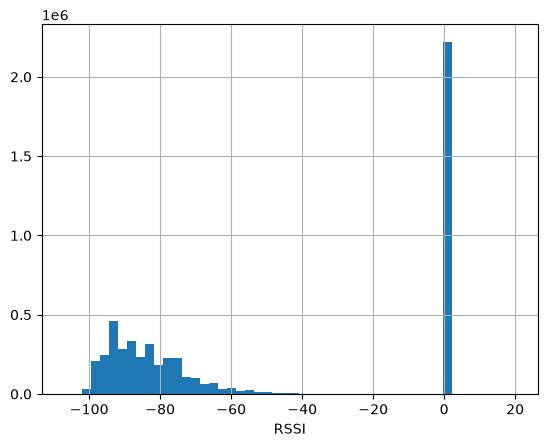

In [18]:
ts = bt.columns[0]   # the timestamp column, whatever it's called
print("days covered:", (bt[ts].max() - bt[ts].min()) / 86400)
print("scan interval (s):", bt[ts].drop_duplicates().sort_values().diff().mode()[0])
print(bt.user_b.value_counts().head())          # expect -1 and -2 near the top
bt.rssi.hist(bins=50); plt.xlabel("RSSI"); plt.show()

rows kept: 2426279 of 5474289
participants: 692


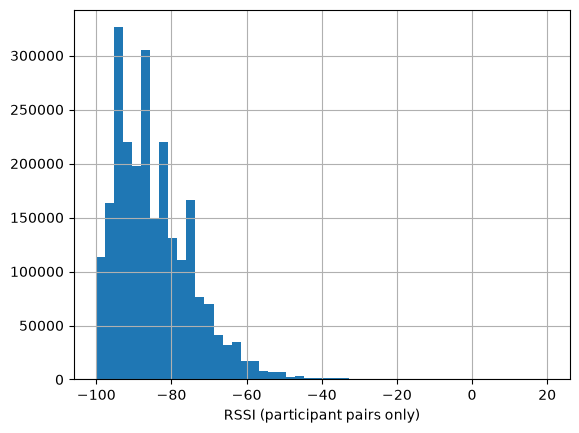

In [19]:
bt_clean = bt[bt.user_b >= 0].copy()
print("rows kept:", len(bt_clean), "of", len(bt))
print("participants:", pd.concat([bt_clean.user_a, bt_clean.user_b]).nunique())
bt_clean.rssi.describe()
bt_clean.rssi.hist(bins=50); plt.xlabel("RSSI (participant pairs only)"); plt.show()

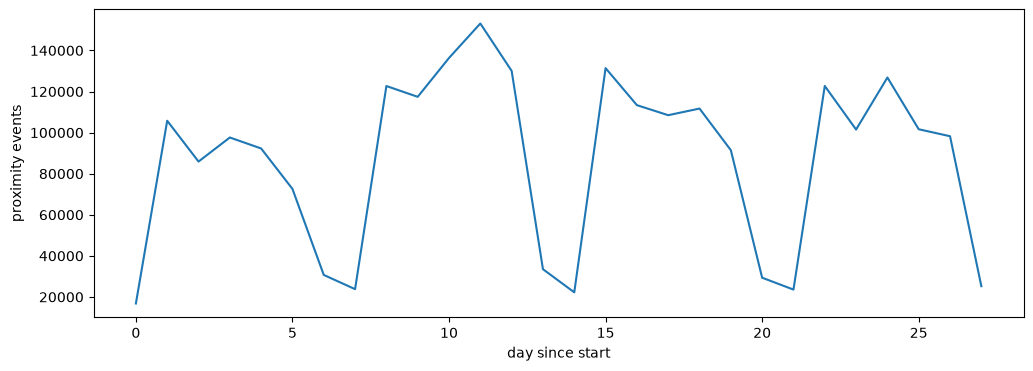

In [20]:
bt_clean["day"] = bt_clean[ts] // 86400
bt_clean.groupby("day").size().plot(figsize=(12,4))
plt.xlabel("day since start"); plt.ylabel("proximity events"); plt.show()

['timestamp', 'caller', 'callee', 'duration'] ['timestamp', 'sender', 'recipient']


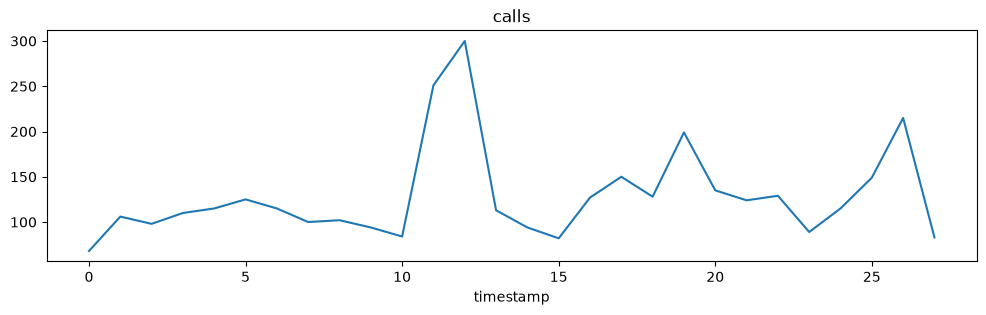

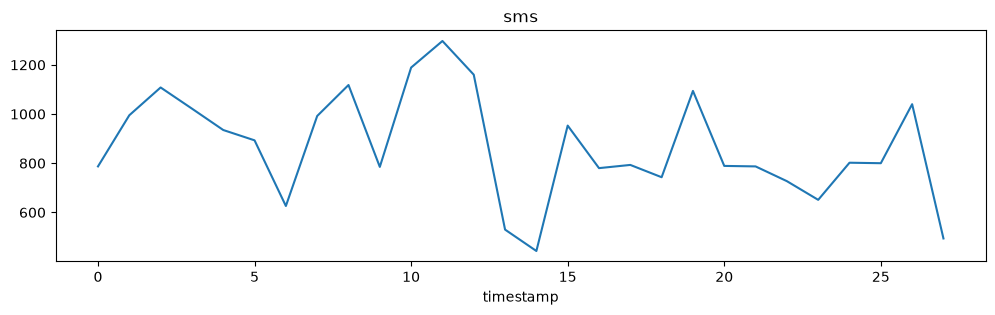

In [21]:
print(calls.columns.tolist(), sms.columns.tolist())
for name, df in [("calls", calls), ("sms", sms)]:
    (df.timestamp // 86400).value_counts().sort_index().plot(title=name, figsize=(12,3)); plt.show()